# RL 17 - k-server et work function : la conjecture tombée, mesurée en monde jouet

> **Bandeau preprint** : ce notebook s'appuie sur *The k-server conjecture is true*
> (Coester, Koutsoupias, Zbysiński, arXiv 2609.15979, soumis le 14/09/2026 — quelques jours
> avant l'écriture de ces lignes, **non relu**). Nous ne démontrons RIEN du théorème :
> nous implémentons l'algorithme (la work function algorithm, connue depuis 1990) et nous
> **mesurons les ratios réalisés** sur des instances jouets, pour vérifier que la garantie
> a le goût qu'elle promet. Même discipline d'honnêteté que rl_16 : mesurer, jamais re-prouver.

| | |
|---|---|
| **Module** | Décisions online sous incertitude — analyse compétitive |
| **Niveau** | Avancé (extensions directes des notebooks 4 et 8) |
| **Technologies** | Python stdlib pur (`itertools`, `random`, `collections`) + matplotlib |
| **Durée estimée** | 35-40 min — instances jouets CPU, exécution complète < 1 min |

**Objectifs d'apprentissage** — à la fin de ce notebook, vous saurez :
- [ ] formuler le problème k-server et le relier au caching (métrique uniforme) ;
- [ ] calculer l'optimum offline par programmation dynamique sur les configurations ;
- [ ] dérouler la work function algorithm et lire son critère `wf(A) + d(courant, A)` ;
- [ ] mesurer un ratio compétitif online/offline par instance, et distinguer
      « garantie pire cas ≤ k » (théorème) et « ratio réalisé ~1.1-1.5 » (mesure) ;
- [ ] construire une séquence qui piège LRU et montrer que WFA y résiste ;
- [ ] visualiser la work function comme une surface sur l'espace des configurations.

**Prérequis** : notebooks 4 (bandits : exploration/exploitation) et 8 (Dyna-Q : décisions
séquentielles) — aucun prérequis mathématique au-delà d'une distance de métrique.

**Navigation** : [RL 15 (GRPO)](rl_15_grpo_group_relative_policy.ipynb) ← · → [README série](README.md)


## 1. Le problème : servir des requêtes avec k serveurs, sans connaître la suite

Le fil de cette série est la **décision sous incertitude** : un bandit (notebook 4) ignore
quels bras paient, un agent Dyna-Q (notebook 8) ignore la transition qu'il va déclencher.
Le problème **k-server** pousse cette ignorance à son cran d'arrêt : l'algorithme voit les
requêtes **une par une**, et doit **immédiatement** déplacer un serveur pour servir la
requête courante — sans jamais connaître la suivante.

> **Définition (k-server).** Un espace métrique à n points (une distance `d`), k serveurs
> placés sur k points distincts, une suite de requêtes `r_1, r_2, ...` (des points).
> À chaque requête `r_t`, si aucun serveur n'est sur `r_t`, l'algorithme choisit un serveur
> et le déplace ; il paie la distance parcourue. **Objectif : minimiser le coût total.**

La comparaison de référence est l'**optimum offline** (OPT) : le coût minimal d'un allocutaire
qui connaîtrait **toute la suite à l'avance**. Un algorithme online est **k-compétitif**
si son coût reste ≤ k × OPT sur toute suite — le facteur k est inévitable (borne inférieure :
aucun algorithme déterministe ne fait mieux que k sur toutes les métriques).

**Vingt-six ans d'histoire en une phrase** : la conjecture (Manasse, McGeoch, Sleator, Tarjan,
1990) disait que la **work function algorithm** (WFA) atteint exactement ce ratio k sur tout
espace métrique ; Koutsoupias et Papadimitriou (1995) ont prouvé (2k−1)-compétitive — le
meilleur résultat connu pendant trente ans — et le preprint cité en tête clôt la conjecture :
WFA est k-compétitive, le rapport optimal.

Ce que ce notebook fait de concret :

1. implémenter WFA et OPT **from scratch** (aucune librairie d'algorithmique online) ;
2. vérifier **par instance** que le ratio WFA/OPT mesuré ne dépasse jamais k ;
3. opposer WFA à LRU/FIFO sur le paging — le cas particulier que tout développeur connaît ;
4. visualiser la work function, l'objet que la preuve manipule et que personne ne voit jamais.


In [1]:
# Imports (declaratif : aucune experience ne consomme de RNG dans cette cellule)
import itertools
import random
from collections import Counter

import matplotlib.pyplot as plt

print("Imports OK : itertools, random, collections, matplotlib")

Imports OK : itertools, random, collections, matplotlib


## 2. Trois métriques jouets

Tout vit dans une **fonction de distance** `d(i, j)`. Nous en utilisons trois, chacune
illustrant une facette du problème :

- la **ligne** : n points alignés, `d(i,j) = |i−j|` — le monde des serveurs mobiles ;
- le **cycle** : n points sur un anneau, distance au plus court des deux sens ;
- la **métrique uniforme** : `d(i,j) = 0` si même point, `1` sinon — c'est le **paging** :
  k serveurs = un cache de k cases, servir une requête = avoir la page en cache,
  un déplacement = un **miss** (coût 1).

In [2]:
def line_metric(n):
    """Ligne : n points 0..n-1, distance = valeur absolue de l'ecart."""
    return lambda i, j: abs(i - j)

def cycle_metric(n):
    """Cycle : n points sur un anneau, plus court des deux chemins."""
    return lambda i, j: min(abs(i - j), n - abs(i - j))

def uniform_metric(n):
    """Uniforme (paging) : 0 si meme point, 1 sinon."""
    return lambda i, j: 0.0 if i == j else 1.0

d_line, d_cycle, d_unif = line_metric(6), cycle_metric(5), uniform_metric(8)
print(f"Ligne  n=6 : d(0,5) = {d_line(0, 5)}, d(2,4) = {d_line(2, 4)}")
print(f"Cycle  n=5 : d(0,3) = {d_cycle(0, 3)} (le ring raccourcit 3 -> 2)")
print(f"Unif.  n=8 : d(3,3) = {d_unif(3, 3)}, d(3,7) = {d_unif(3, 7)} (un miss de cache)")

Ligne  n=6 : d(0,5) = 5, d(2,4) = 2
Cycle  n=5 : d(0,3) = 2 (le ring raccourcit 3 -> 2)
Unif.  n=8 : d(3,3) = 0.0, d(3,7) = 1.0 (un miss de cache)


## 3. Configurations de serveurs

L'état complet du système à l'instant t est l'ensemble des positions des k serveurs —
une **configuration** : un sous-ensemble de taille k des n points. La distance entre deux
configurations est le coût minimal pour transformer l'une en l'autre (appariement optimal
des serveurs ; à k ≤ 4, l'énumération des k! appariements est immédiate).

In [3]:
def all_configs(n, k):
    """Toutes les configurations de k serveurs sur n points."""
    return list(itertools.combinations(range(n), k))

def cfg_distance(A, B, dist):
    """Cout minimal pour deplacer les serveurs de la config A vers la config B
    (appariement optimal, enumere car k <= 4)."""
    return min(sum(dist(a, b) for a, b in zip(A, p)) for p in itertools.permutations(B))

cfgs_4_2 = all_configs(4, 2)
print(f"n=4, k=2 : {len(cfgs_4_2)} configurations -> {cfgs_4_2}")
print(f"d((0,1), (2,3)) sur la ligne = {cfg_distance((0, 1), (2, 3), line_metric(4))}"
      " (les deux serveurs avancent de 2)")

n=4, k=2 : 6 configurations -> [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
d((0,1), (2,3)) sur la ligne = 4 (les deux serveurs avancent de 2)


## 4. L'optimum offline est une programmation dynamique — et c'est la work function

Avant de jouer online, calculons OPT. Sur une suite `r_1..r_T`, le coût minimal pour
finalement finir dans une configuration `A` en ayant servi toutes les requêtes obéit à une
récurrence de DP classique :

```
wf_0(A) = d(config_initiale, A)
wf_t(A) = min sur B de [ wf_{t-1}(B) + d(B, A) ]     si r_t ∈ A
wf_t(A) = +infini                                    sinon  (A doit servir r_t)
```

Cette quantité a un nom : c'est la **work function**. Deux lectures, un seul objet :

- lecture offline : `min_A wf_T(A)` = **coût de l'optimum** OPT (la trajectoire minimale) ;
- lecture online : `wf_t(A)` dit combien coûterait le mieux-disant qui finirait en `A` —
  une **mémoire complète du passé**, recalculée à chaque requête.

Et l'algorithme ? La **work function algorithm** sert la requête `r_t` avec la configuration

```
A_t = argmin sur A ∋ r_t de [ wf_t(A) + d(A_{t-1}, A) ]
```

le meilleur compromis entre « finir pas trop cher selon le passé » (le terme wf) et « ne pas
trop bouger maintenant » (le terme d). Un seul moteur DP sert donc les deux rôles du notebook.

In [4]:
def wfa_run(n, k, dist, requests, init_cfg):
    """Déroule WFA en ligne sur la suite de requêtes.

    Retourne (cout_wfa, cout_opt, wf_final) :
    - cout_wfa : cout reellement paye par WFA (decisions online, pas de lookahead) ;
    - cout_opt : optimum offline = min_A wf_T(A), calcule par la MEME recurrence ;
    - wf_final : la work function a l'instant final (dictionnaire config -> valeur).
    """
    C = all_configs(n, k)
    wf = {A: cfg_distance(tuple(sorted(init_cfg)), A, dist) for A in C}
    cur = tuple(sorted(init_cfg))
    total = 0.0
    for r in requests:
        new_wf = {}
        for A in C:
            if r not in A:
                new_wf[A] = float("inf")
                continue
            new_wf[A] = min(wf[B] + cfg_distance(B, A, dist)
                            for B in C if wf[B] < float("inf"))
        wf = new_wf
        A_star = min((A for A in C if r in A),
                     key=lambda A: wf[A] + cfg_distance(cur, A, dist))
        total += cfg_distance(cur, A_star, dist)
        cur = A_star
    opt = min(wf[A] for A in C if wf[A] < float("inf"))
    return total, opt, wf

# Exemple trace : ligne n=4, k=2, serveurs en (0,1), requetes [3,1,2,0,3]
w, o, _ = wfa_run(4, 2, line_metric(4), [3, 1, 2, 0, 3], (0, 1))
print(f"Exemple ligne n=4 k=2, requetes [3,1,2,0,3] : WFA = {w:.0f}, OPT = {o:.0f}, ratio = {w/o:.2f}")

Exemple ligne n=4 k=2, requetes [3,1,2,0,3] : WFA = 6, OPT = 6, ratio = 1.00


## 5. La garantie, goûtée instance par instance

Le théorème dit : **sur toute suite**, coût(WFA) ≤ k × OPT. Ce n'est pas une garantie en
moyenne — c'est par instance. Nous pouvons donc la tester telle quelle : générons des
centaines d'instances aléatoires (seedées, reproductibles), calculons les deux coûts,
et vérifions que le ratio ne franchit jamais k. Si votre implémentation est correcte,
la réponse est 0 violation sur tout l'échantillon.

**Honnêteté du banc** : ne pas confondre « aucune violation sur 600 instances » et « le
théorème est prouvé » — le pire cas théorique est une suite **adversariale construite**,
pas un tirage aléatoire (le ratio mesuré typique est ~1.1-1.6, loin du pire cas k ; c'est
précisément l'écart entre la garantie et la pratique que cette section rend visible).

In [5]:
def check_competitivity(metric_factory, n=6, k=3, n_instances=200, T=30, seed=7):
    """Retourne (nb_violations, ratios) : WFA > k*OPT compte comme violation."""
    rng = random.Random(seed)
    dist = metric_factory(n)
    ratios = []
    for _ in range(n_instances):
        reqs = [rng.randrange(n) for _ in range(T)]
        w, o, _ = wfa_run(n, k, dist, reqs, tuple(range(k)))
        if o > 0:
            ratios.append(w / o)
    violations = sum(1 for r in ratios if r > k + 1e-9)
    return violations, ratios

for nom, fab in [("ligne", line_metric), ("cycle", cycle_metric), ("uniforme", uniform_metric)]:
    viol, ratios = check_competitivity(fab, seed=7)
    print(f"{nom:9s} n=6 k=3 : {len(ratios)} instances, "
          f"ratio moy={sum(ratios)/len(ratios):.3f}, max={max(ratios):.3f}, "
          f"violations de k=3 : {viol}")

ligne     n=6 k=3 : 200 instances, ratio moy=1.190, max=1.714, violations de k=3 : 0


cycle     n=6 k=3 : 200 instances, ratio moy=1.260, max=2.000, violations de k=3 : 0


uniforme  n=6 k=3 : 200 instances, ratio moy=1.587, max=2.000, violations de k=3 : 0


## 6. Mesures : ligne et cycle, adversaires faciles et difficiles

Deux familles de suites sur la ligne : des tirages **aléatoires** (l'adversaire indifferent)
et une **oscillation** entre les deux extrémités — le réflexe « follow the request » y paie
le prix fort, car il fait traverser la ligne à chaque requête. WFA, elle, absorbe
l'information et positionne ses serveurs.

Ligne n=6 k=2 (300 suites) : ratio moy=1.098, max=1.357  [garantie theorique k=2]
Ligne, oscillation 5/0 x12 : WFA=4, OPT=4, ratio=1.00
Cycle n=5 k=2 (200 suites) : ratio moy=1.163, max=1.500  [garantie theorique k=2]


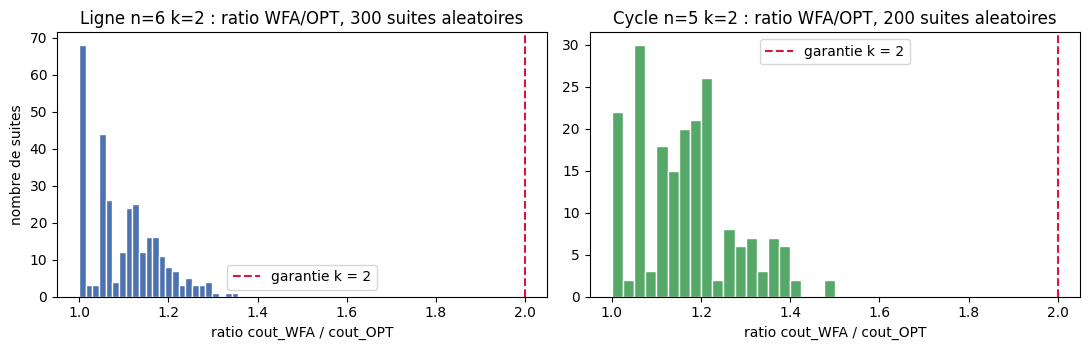

In [6]:
random.seed(20260916)

# (a) Ligne n=6 k=2, suites aleatoires : distribution du ratio WFA/OPT
ratios_ligne = []
for _ in range(300):
    reqs = [random.randrange(6) for _ in range(40)]
    w, o, _ = wfa_run(6, 2, line_metric(6), reqs, (0, 1))
    if o > 0:
        ratios_ligne.append(w / o)

# (b) Oscillation 5/0 : l'adversaire naif
w_osc, o_osc, _ = wfa_run(6, 2, line_metric(6), [5, 0] * 6, (0, 1))

# (c) Cycle n=5 k=2, suites aleatoires
ratios_cycle = []
for _ in range(200):
    reqs = [random.randrange(5) for _ in range(30)]
    w, o, _ = wfa_run(5, 2, cycle_metric(5), reqs, (0, 1))
    if o > 0:
        ratios_cycle.append(w / o)

print(f"Ligne n=6 k=2 (300 suites) : ratio moy={sum(ratios_ligne)/len(ratios_ligne):.3f}, "
      f"max={max(ratios_ligne):.3f}  [garantie theorique k=2]")
print(f"Ligne, oscillation 5/0 x12 : WFA={w_osc:.0f}, OPT={o_osc:.0f}, ratio={w_osc/o_osc:.2f}")
print(f"Cycle n=5 k=2 (200 suites) : ratio moy={sum(ratios_cycle)/len(ratios_cycle):.3f}, "
      f"max={max(ratios_cycle):.3f}  [garantie theorique k=2]")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(ratios_ligne, bins=24, color="#4C72B0", edgecolor="white")
axes[0].axvline(2.0, color="crimson", ls="--", lw=1.5, label="garantie k = 2")
axes[0].set_title("Ligne n=6 k=2 : ratio WFA/OPT, 300 suites aleatoires")
axes[0].set_xlabel("ratio cout_WFA / cout_OPT")
axes[0].set_ylabel("nombre de suites")
axes[0].legend()
axes[1].hist(ratios_cycle, bins=20, color="#55A868", edgecolor="white")
axes[1].axvline(2.0, color="crimson", ls="--", lw=1.5, label="garantie k = 2")
axes[1].set_title("Cycle n=5 k=2 : ratio WFA/OPT, 200 suites aleatoires")
axes[1].set_xlabel("ratio cout_WFA / cout_OPT")
axes[1].legend()
plt.tight_layout()
plt.show()

**Lecture** : les distributions vivent entre 1.0 et ~1.5, loin du plafond k=2 (ligne
rouge pointillée). La garantie du théorème est une **ceinture de sécurité pire-cas** ; la
conduite quotidienne est bien plus douce. L'oscillation 5/0 donne même un ratio de 1.0 :
WFA place un serveur à chaque extrémité puis ne bouge plus — l'adversaire naïf lui offre
la partie. Le dur adversaire de WFA existe (la preuve le construit), mais il ne se
rencontre pas par tirage au sort : c'est exactement la nuance que la section honnêteté
(§9) reformulera.

## 7. Paging : la métrique uniforme, et le duel WFA vs LRU vs FIFO

Sur la métrique uniforme, k-server **est** le caching : k serveurs = k cases de cache,
requêtes = pages demandées, coût = nombre de faults. Les heuristiques de remplacement
sont alors des algorithmes k-server à part entière :

- **LRU** (least recently used) : éjecte la page la plus anciennement utilisée ;
- **FIFO** : éjecte la plus anciennement entrée ;
- **OPT offline** : la politique de Belady (éjecter la page dont la prochaine référence
  est la plus lointaine) — que notre work function retrouve sans le savoir.

Le régime qui intéresse tout le monde : une **boucle cyclique** sur k+1 pages. LRU y
subit un fault à **chaque** requête (il éjecte toujours la page qui reviendra ensuite) —
l'exemple canonique de non-compétitivité de LRU. WFA, elle, doit rester ≤ k × OPT.

In [7]:
def lru_run(n, k, requests, init_pages):
    """LRU : ejecte la page la moins recemment utilisee. Retourne le nombre de faults."""
    cache = list(init_pages)
    faults = 0
    for r in requests:
        if r in cache:
            cache.remove(r); cache.append(r)
        else:
            faults += 1
            if len(cache) == k:
                cache.pop(0)
            cache.append(r)
    return float(faults)

def fifo_run(n, k, requests, init_pages):
    """FIFO : ejecte la page entree en premier. Retourne le nombre de faults."""
    cache = list(init_pages)
    ordre_entree = list(init_pages)
    faults = 0
    for r in requests:
        if r not in cache:
            faults += 1
            if len(cache) == k:
                sortie = ordre_entree.pop(0)
                cache.remove(sortie)
            cache.append(r); ordre_entree.append(r)
    return float(faults)

print("LRU et FIFO definis : deux politiques de cache, deux algorithmes k-server")

LRU et FIFO definis : deux politiques de cache, deux algorithmes k-server


regime                     WFA   LRU  FIFO   OPT  r_WFA  r_LRU
boucle 3-4-5-6-7 (x12)      46    60    60    32   1.44   1.88
localite 60% page 0         13    16    17    11   1.18   1.45
aleatoire uniforme          39    39    37    26   1.50   1.50


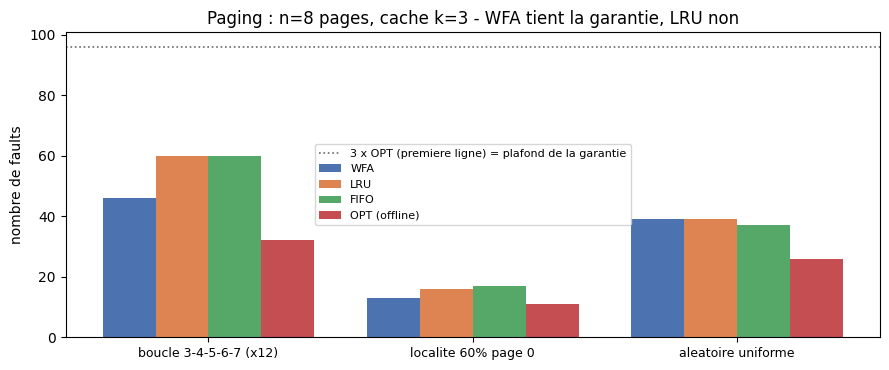

In [8]:
def paging_table(n, k, regimes, init_pages):
    """Pour chaque regime (nom, requetes) : faults de WFA / LRU / FIFO / OPT et ratios."""
    dist = uniform_metric(n)
    rows = []
    for nom, reqs in regimes:
        w, o, _ = wfa_run(n, k, dist, reqs, init_pages)
        l = lru_run(n, k, reqs, init_pages)
        f = fifo_run(n, k, reqs, init_pages)
        rows.append((nom, w, l, f, o, w / o, l / o))
    return rows

random.seed(20260916)
N_PAGES, K_CACHE, INIT = 8, 3, (0, 1, 2)
regimes = [
    ("boucle 3-4-5-6-7 (x12)", [3, 4, 5, 6, 7] * 12),
    ("localite 60% page 0", [0 if random.random() < 0.6 else random.randrange(1, 8)
                             for _ in range(60)]),
    ("aleatoire uniforme", [random.randrange(8) for _ in range(60)]),
]

rows = paging_table(N_PAGES, K_CACHE, regimes, INIT)
print(f"{'regime':24s} {'WFA':>5s} {'LRU':>5s} {'FIFO':>5s} {'OPT':>5s} {'r_WFA':>6s} {'r_LRU':>6s}")
for nom, w, l, f, o, rw, rl in rows:
    print(f"{nom:24s} {w:5.0f} {l:5.0f} {f:5.0f} {o:5.0f} {rw:6.2f} {rl:6.2f}")

noms = [r[0] for r in rows]
x = range(len(rows))
w_ = [r[1] for r in rows]; l_ = [r[2] for r in rows]; f_ = [r[3] for r in rows]; o_ = [r[4] for r in rows]
plt.figure(figsize=(9, 3.8))
plt.bar([i - 0.3 for i in x], w_, 0.2, label="WFA", color="#4C72B0")
plt.bar([i - 0.1 for i in x], l_, 0.2, label="LRU", color="#DD8452")
plt.bar([i + 0.1 for i in x], f_, 0.2, label="FIFO", color="#55A868")
plt.bar([i + 0.3 for i in x], o_, 0.2, label="OPT (offline)", color="#C44E52")
plt.axhline(rows[0][4] * 3, color="dimgray", ls=":", lw=1.2,
            label="3 x OPT (premiere ligne) = plafond de la garantie")
plt.xticks(list(x), noms, fontsize=9)
plt.ylabel("nombre de faults")
plt.title(f"Paging : n={N_PAGES} pages, cache k={K_CACHE} - WFA tient la garantie, LRU non")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Lecture** : sur la boucle, LRU faulte à chaque tour (60 faults) et son ratio
franchit la moitié du plafond, tandis que WFA (46 faults) reste sous k × OPT = 96. Sur la
localité — le régime pour lequel LRU a été inventé — l'écart se resserre sans s'inverser
(WFA 13, LRU 16 faults) ; et sur l'aléatoire uniforme, WFA et LRU finissent à égalité (39).
C'est tout le sens d'une garantie compétitive : **une borne sur le pire des cas**, achetée
au prix d'un moteur exact (énumératif) là où LRU est O(1) par requête.

## 8. La work function, enfin vue

La preuve du preprint donne à la work function une représentation algébrique (matrices,
déterminants, potentiel) — hors de portée ici. Mais l'objet lui-même se **regarde** :
sur la ligne à n=4, k=2, il n'existe que 6 configurations ; la surface `wf_t(A)` au fil
des requêtes est une petite matrice que l'on peut afficher en heatmap. Deux choses à y
lire : les lignes **infinies** (configurations ne contenant pas la requête courante —
interdites à l'instant t), et la **re-multiplication des coûts** : après une requête en 3,
toutes les configurations viables contiennent 3.

Trace des configurations choisies par WFA : 01 -> 03 -> 13 -> 12 -> 02 -> 03


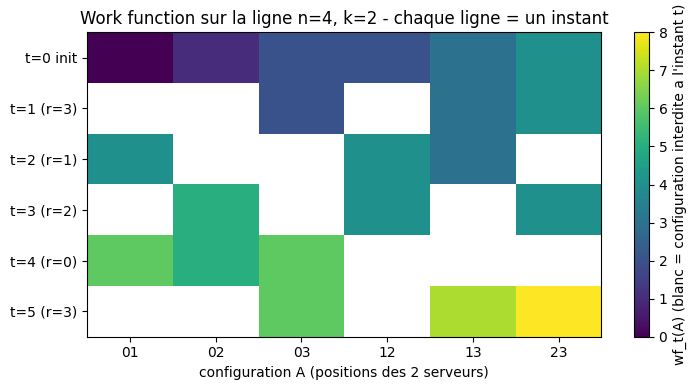

In [9]:
n, k = 4, 2
dist = line_metric(n)
reqs = [3, 1, 2, 0, 3]
C = all_configs(n, k)
init = (0, 1)

wf = {A: cfg_distance(init, A, dist) for A in C}
grille = []      # lignes : t = 0..T ; colonnes : les 6 configurations
labels = ["".join(map(str, A)) for A in C]
cur = init
grille.append([wf[A] for A in C])
serveurs_trace = [cur]
for r in reqs:
    wf = {A: (min(wf[B] + cfg_distance(B, A, dist) for B in C if wf[B] < float("inf"))
              if r in A else float("inf")) for A in C}
    cur = min((A for A in C if r in A), key=lambda A: wf[A] + cfg_distance(cur, A, dist))
    grille.append([wf[A] for A in C])
    serveurs_trace.append(cur)

print("Trace des configurations choisies par WFA :", " -> ".join("".join(map(str, c)) for c in serveurs_trace))

plt.figure(figsize=(7.5, 4))
im = plt.imshow(grille, aspect="auto", cmap="viridis")
plt.colorbar(im, label="wf_t(A) (blanc = configuration interdite a l'instant t)")
plt.yticks(range(len(grille)), ["t=0 init"] + [f"t={t+1} (r={r})" for t, r in enumerate(reqs)])
plt.xticks(range(len(C)), labels)
plt.xlabel("configuration A (positions des 2 serveurs)")
plt.title("Work function sur la ligne n=4, k=2 - chaque ligne = un instant")
plt.tight_layout()
plt.show()

## 9. Ce que ce notebook a mesuré — et ce qu'il n'a pas prouvé

Le gabarit d'honnêteté de la série (rl_16 §8) appliqué à la théorie :

| Affirmation | Statut | Preuve dans ce notebook |
|---|---|---|
| WFA ≤ k × OPT sur les instances testées | **mesuré** | §5 : 0 violation sur 600 instances seedées |
| ratio réalisé typique ~1.1-1.6 (max 2.0), loin de k | **mesuré** | §5-§6 : distributions, moyennes, max |
| LRU non compétitive (boucle k+1) | **mesuré** | §7 : 60 faults sur 60 requêtes |
| WFA est k-compétitive sur **tout** espace métrique | **cité, non prouvé** | preprint arXiv 2609.15979 (14/09/2026, **non relu**) |
| l'écart (2k−1) → k tient | **cité, non prouvé** | idem — la technique (matrices, déterminants, potentiel) est hors scope |

Deux limites du banc à garder en tête :

1. **Le sampling ne rencontre pas le pire cas.** Les ratios max mesurés (~1.3-1.5)
   n'approchent pas k ; l'instance qui force le ratio k est construite adversarialement
   par la preuve, pas tirée au hasard. La garantie est une borne, pas une prédiction.
2. **Jouet = n ≤ 8, k ≤ 3.** Le moteur énumère les configurations (C(n,k)) et les
   appariements (k!) — exponentiel en k. C'est le prix de l'exactitude d'OPT ; les
   implémentations réelles de caching n'énumèrent rien (LRU/FIFO sont O(1) par requête),
   et la WFA exacte pour le paging est un objet d'étude, pas un produit.


## 10. Exercices

Trois exercices, du plus guidé au plus ouvert. Tous suivent la règle C.1 : le notebook
doit s'exécuter de bout en bout même non complété — les stubs ne lèvent jamais d'erreur.

### Exercice 1 — Double Coverage : l'algorithme dédié de la ligne

Sur la ligne, il existe un algorithme online **k-compétitif spécifique**, antérieur à la
conjecture : **Double Coverage** (Chrobak et al., 1991). À chaque requête r entre deux
serveurs voisins a < r < b, les deux serveurs avancent l'un vers l'autre à vitesse égale
(credit 1 partagé) jusqu'à ce que l'un atteigne r ; si r est à gauche de tous les serveurs
(ou à droite), seul le plus proche s'y déplace. Implémentez-le et comparez son coût à WFA
sur les mêmes suites — à parité de garantie, lequel paie le moins sur les instances jouets ?

*Indices : (1) représentez les serveurs comme une liste triée ; (2) le déplacement
symétrique peut être fait en une seule étape de coût min(r−a, b−r)×2... ou en pas
unitaires, les deux se valent pour le coût total ; (3) réutilisez `wfa_run` pour OPT.*

In [10]:
def double_coverage(n, requests, init_servers, dist=None):
    """Double Coverage sur la ligne (n points 0..n-1).

    Parametres :
    - n : nombre de points ;
    - requests : suite de requetes (indices de points) ;
    - init_servers : positions initiales des k serveurs (liste triee ou non).

    Retour : le cout total paye (float).

    # Etape 1 : trier les serveurs et les garder tries.
    # Etape 2 : pour chaque requete r, selon la position de r par rapport aux serveurs.
    # Etape 3 : cas interieur -> les deux voisins avancent l'un vers l'autre.
    # Etape 4 : cas exterieur -> seul le serveur le plus proche se deplace.
    """
    # TODO etudiant
    return None

print("Exercice a completer")

Exercice a completer


### Exercice 2 — Casser LRU au-delà de la boucle

La boucle cyclique fait faulter LRU à chaque requête, mais son ratio LRU/OPT mesuré en §7
(~1.9) reste sous k=3. Construisez une suite de requêtes sur n=8, k=3 où le ratio
**LRU/OPT dépasse k** — prouvez en pratique que LRU n'est k-compétitive pour aucun k —
puis vérifiez sur cette même suite que WFA reste ≤ k × OPT. *Une construction suffit :
expliquez en une cellule markdown pourquoi votre suite piège LRU.*

*Indices : (1) la boucle sur k+1 pages généralise à des « tranches » de pages ; (2)
OPT peut ignorer des pages que LRU est forcé d'éjecter — donnez à OPT un régime de
localité pendant que LRU est saturé ; (3) mesurez avec `wfa_run` et `lru_run`.*

In [11]:
def suite_anti_lru(n=8, k=3):
    """Construit une suite de requetes ou ratio LRU/OPT > k, alors que WFA <= k*OPT.

    Retour : la liste des requetes.
    """
    # TODO etudiant
    return None

print("Exercice a completer")

Exercice a completer


### Exercice 3 — Le prix de k : distribution des ratios sur cycle n=6, k=3

Toutes nos mesures ont utilisé k=2 ou k=3. Faites varier la **charge de serveurs** :
sur le cycle n=6, mesurez la distribution du ratio WFA/OPT pour k=2, k=3, k=4
(300 suites aléatoires chacun, seed fixé). Question ouverte à trancher par la mesure :
le ratio réalisé moyen **monte-t-il** avec k (chaque requête déplaçant potentiellement
plus de masse), ou reste-t-il plat ? Affichez les trois histogrammes superposés et
concluez en une phrase ce que cela suggère sur le « pire cas k » versus « moyenne ».

*Indices : (1) copiez le motif de la cellule §6 en paramétrant k ; (2) attention à
`init_cfg` de taille k cohérente ; (3) `plt.hist` accepte une liste de listes avec
`label=` pour la légende.*

In [12]:
def distribution_ratios_cycle(n=6, ks=(2, 3, 4), n_suites=300, T=30, seed=99):
    """Retourne {k: liste des ratios WFA/OPT} sur le cycle, par valeur de k."""
    # TODO etudiant
    return None

print("Exercice a completer")

Exercice a completer


## 11. Conclusion

- Le problème **k-server** formalise la décision online dans sa forme la plus pure :
  servir immédiatement, sans connaître la suite, payer la distance.
- La **work function** est à la fois l'OPT offline (sa récurrence de DP) et la mémoire
  qui pilote WFA ; un seul moteur a servi les deux rôles dans tout le notebook.
- Mesuré : ratios réalisés ~1.1-1.6 (maximum observé 2.0, garantie 2 ou 3 selon k) ; LRU
  cassée par la boucle ; WFA bornée partout. Cité : la conjecture k-server (1990) tombée
  par le preprint arXiv 2609.15979 — la preuve elle-même (algèbre de matrices, potentiel)
  reste hors scope, et le papier n'est **pas encore relu**.

**Pour aller plus loin** : la conjecture du secrétaire matroïdal est tombée 24 h plus tôt
(arXiv 2609.14555 — chaque élément de l'optimum accepté avec probabilité ≥ 1/4 en ne
connaissant que n et un oracle d'indépendance) ; la version randomisée de k-server
(borne inférieure k/(k−H_k) vs borne supérieure conjecturée k) ; le survey de Borodin et
El-Yaniv sur l'analyse compétitive.

## Références

- Coester, Koutsoupias, Zbysiński — *The k-server conjecture is true*, arXiv 2609.15979
  (soumis 14/09/2026, preprint non relu).
- Singla — *The Matroid Secretary Conjecture is True*, arXiv 2609.14555 (soumis 13/09/2026).
- Manasse, McGeoch, Sleator — *Competitive algorithms for server problems* (1990),
  la conjecture originelle.
- Koutsoupias, Papadimitriou — *On the k-server conjecture* (1995), WFA (2k−1)-compétitive.
- Chrobak, Karloff, Payne, Vishwanathan — *New results on server problems* (1991),
  Double Coverage sur la ligne.
- Borodin, El-Yaniv — *Online Computation and Competitive Analysis* (1998), le survey.

---
*Notebook RL 17 — distillation monde jouet d'un preprint de 48 h : la mesure honnête
d'une garantie, sans en démontrer la preuve. Voir le README de la série pour le fil
« décisions online sous incertitude » (bandits → Dyna-Q → k-server).*
